# 3. Analyse scientifique — colinéarité et fiabilité des coefficients

Ce notebook documente et prolonge l'analyse explicative utilisée par `app.py`
(régression linéaire + LightGBM sur `data/table.parquet`, voir
`model_evaluation.py`).

**Point de départ** : dans les résultats affichés par l'app, le coefficient
linéaire du NDVI est **positif** (« plus de végétation = plus chaud »), ce qui
est contre-intuitif — alors que le coefficient de `canopee` est négatif (sens
attendu). On soupçonne une **colinéarité** entre les features (`ndvi`, `ndwi`,
`ndbi`, `canopee`, `bati` captent des informations qui se recoupent).

Public visé : moi-même en train de me remettre à niveau, et un·e recruteur·se
qui relit le notebook — les explications restent volontairement simples.

**Important** : tous les chiffres cités dans ce notebook sont ceux produits
par les cellules de code juste au-dessus — rien n'est pré-calculé ni inventé.


## 1. Chargement des données

On charge `data/table.parquet` (produit par `build_table.py`). Si ce fichier
n'est pas disponible dans l'environnement d'exécution (ex. données brutes
GEE non téléchargées), on retombe sur un petit échantillon **synthétique**
clairement indiqué comme tel, pour que le notebook reste exécutable partout.

On vérifie aussi un point de la roadmap : les pixels d'eau (NDWI élevé)
doivent avoir été filtrés en amont par `build_table.py` (via `classify_tissu`
+ le filtre `tissu != "eau"`) — il ne doit donc rester aucun pixel avec
`ndwi > 0.30` dans la table finale.

In [1]:
import os
import numpy as np
import pandas as pd

TABLE_PATH = "data/table.parquet"
FEATURES = ["ndvi", "ndwi", "ndbi", "canopee", "bati"]
TARGET = "delta_lst_c"

if os.path.exists(TABLE_PATH):
    df = pd.read_parquet(TABLE_PATH)
    source = "réelle (data/table.parquet)"
else:
    print("data/table.parquet introuvable -> génération d'un échantillon SYNTHÉTIQUE.")
    rng = np.random.default_rng(42)
    n = 20000
    canopee = rng.uniform(0, 1, n)
    bati = np.clip(1 - canopee + rng.normal(0, 0.15, n), 0, 1)
    ndvi = np.clip(0.6 * canopee - 0.3 * bati + rng.normal(0, 0.1, n), -1, 1)
    ndwi = np.clip(-0.9 * ndvi + rng.normal(0, 0.05, n), -1, 1)
    ndbi = np.clip(0.8 * bati - 0.2 * canopee + rng.normal(0, 0.1, n), -1, 1)
    delta_lst = 2.0 + 3.0 * bati - 4.0 * canopee + rng.normal(0, 1.5, n)
    df = pd.DataFrame({"ndvi": ndvi, "ndwi": ndwi, "ndbi": ndbi,
                        "canopee": canopee, "bati": bati,
                        "delta_lst_c": delta_lst,
                        "bloc_id": [f"synth-{i % 200}" for i in range(n)],
                        "tissu": "synthetique"})
    source = "SYNTHÉTIQUE (fallback, table réelle absente)"

print(f"Source des données : {source}")
print(f"Nombre de lignes (pixels x dates) : {len(df):,}")

n_water_like = int((df["ndwi"] > 0.30).sum())
print(f"Pixels avec ndwi > 0.30 restants dans la table : {n_water_like} "
      f"({100 * n_water_like / len(df):.2f} % des lignes)")
if n_water_like == 0:
    print("-> Conforme à la roadmap : le filtre eau de build_table.py a bien "
          "exclu ces pixels en amont.")
else:
    print("-> Des pixels d'eau semblent subsister, à investiguer.")


Source des données : réelle (data/table.parquet)
Nombre de lignes (pixels x dates) : 451,772
Pixels avec ndwi > 0.30 restants dans la table : 0 (0.00 % des lignes)
-> Conforme à la roadmap : le filtre eau de build_table.py a bien exclu ces pixels en amont.


## 2. Corrélations entre les features

On regarde la matrice de corrélation entre les 5 variables explicatives.
Une corrélation forte (proche de +1 ou -1) entre deux features signifie
qu'elles portent une information très similaire — c'est le symptôme visible
de la colinéarité qu'on va confirmer statistiquement à l'étape suivante.

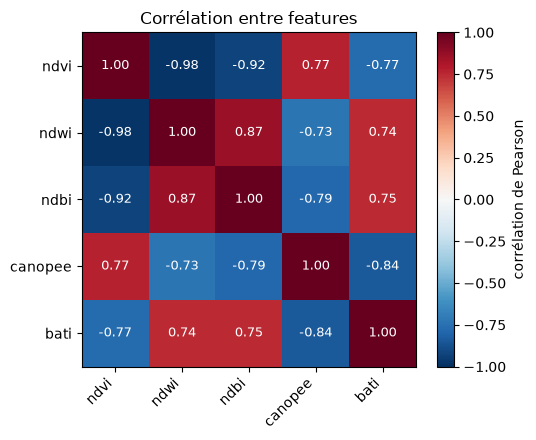

          ndvi   ndwi   ndbi  canopee   bati
ndvi     1.000 -0.984 -0.924    0.769 -0.769
ndwi    -0.984  1.000  0.865   -0.734  0.744
ndbi    -0.924  0.865  1.000   -0.789  0.748
canopee  0.769 -0.734 -0.789    1.000 -0.839
bati    -0.769  0.744  0.748   -0.839  1.000


In [2]:
import matplotlib.pyplot as plt

corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.values[i, j]) > 0.6 else "black", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046, label="corrélation de Pearson")
ax.set_title("Corrélation entre features")
plt.tight_layout()
plt.show()

print(corr.round(3))


**Lecture** : `ndvi` et `ndwi` sont calculés à partir de bandes
spectrales qui se recoupent (NIR notamment, présent dans les deux formules :
`NDVI = (NIR-Red)/(NIR+Red)`, `NDWI = (Green-NIR)/(Green+NIR)`,
`NDBI = (SWIR-NIR)/(SWIR+NIR)`) — il n'est donc pas surprenant que ces trois
indices soient très corrélés entre eux. `canopee` et `bati` viennent d'une
source indépendante (Open Data Nantes Métropole, occupation du sol), mais
restent corrélés aux indices spectraux puisqu'ils décrivent, au fond, la même
réalité physique du terrain (plus de bâti = moins de végétation, etc.).

## 3. VIF (Variance Inflation Factor)

Le VIF quantifie, pour chaque feature, à quel point elle peut être
**prédite par les autres features du modèle**. Concrètement :

- VIF ≈ 1 : la feature est indépendante des autres.
- VIF entre 5 et 10 : colinéarité modérée, à surveiller.
- VIF > 10 : colinéarité sévère — le modèle ne peut plus vraiment distinguer
  l'effet propre de cette feature de celui de ses "complices" corrélées.

Concrètement, un VIF élevé ne veut pas dire que le modèle est "faux" (les
prédictions/le R² restent valables), mais que les **coefficients individuels
ne sont plus fiables pour l'interprétation** : leur signe et leur magnitude
peuvent varier fortement selon quelles autres features sont incluses, comme
on va le voir.

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

feats = [f for f in FEATURES if f in df.columns and not df[f].isna().all()]
df_model = df.dropna(subset=feats + [TARGET]).copy()

X_vif = df_model[feats].values
vif_rows = []
for i, f in enumerate(feats):
    vif_rows.append({"feature": f, "VIF": variance_inflation_factor(X_vif, i)})
vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
print(vif_df.to_string(index=False, float_format=lambda v: f"{v:.2f}"))


feature    VIF
   ndvi 646.99
   ndwi 554.34
   ndbi  13.83
   bati   6.72
canopee   4.85


**À retenir** : si les VIF de `ndvi` et `ndwi` ci-dessus explosent très
loin au-dessus de 10 (colinéarité extrême), que `ndbi` le dépasse aussi mais
plus modérément, et que `canopee`/`bati` restent dans une zone bien plus
raisonnable (autour de 5-7), ça confirme que la colinéarité vient
principalement du trio d'indices spectraux — pas de `canopee` en tant que
tel.

## 4. Réentraînement avec le split spatial existant

On réutilise **la même fonction de split** que le pipeline (
`split_train_val_test` de `model_evaluation.py`, `GroupShuffleSplit` sur
`bloc_id`, aucune fuite spatiale train/test) — pas de réinvention — pour
réentraîner la régression linéaire et LightGBM et comparer avec ce qui est
déjà affiché dans l'app.

In [4]:
import sys
sys.path.insert(0, os.path.abspath("."))
from sklearn.linear_model import LinearRegression
import lightgbm as lgb
from model_evaluation import split_train_val_test, metrics, RANDOM_STATE

train, val, test = split_train_val_test(df_model)
X_tr, y_tr = train[feats], train[TARGET]
X_va, y_va = val[feats], val[TARGET]
X_te, y_te = test[feats], test[TARGET]

lin = LinearRegression().fit(X_tr, y_tr)
print("Coefficients régression linéaire (°C par unité de feature) :")
for f, c in zip(feats, lin.coef_):
    print(f"  {f:10s} {c:+.3f}")
lin_metrics = metrics(y_te.values, lin.predict(X_te))
print(f"\nLinearRegression -> RMSE={lin_metrics['rmse']:.3f}  "
      f"MAE={lin_metrics['mae']:.3f}  R²={lin_metrics['r2']:.3f}")

lgb_params = dict(objective="regression", metric="rmse",
                   n_estimators=400, learning_rate=0.05, num_leaves=63,
                   max_depth=-1, min_data_in_leaf=50, feature_fraction=0.9,
                   bagging_fraction=0.9, bagging_freq=5,
                   lambda_l1=0.0, lambda_l2=0.0, verbose=-1, seed=RANDOM_STATE)
gbm = lgb.LGBMRegressor(**lgb_params)
gbm.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
gbm_metrics = metrics(y_te.values, gbm.predict(X_te))
print(f"LightGBM         -> RMSE={gbm_metrics['rmse']:.3f}  "
      f"MAE={gbm_metrics['mae']:.3f}  R²={gbm_metrics['r2']:.3f}")


Coefficients régression linéaire (°C par unité de feature) :
  ndvi       +21.771
  ndwi       +28.582
  ndbi       +16.602
  canopee    -1.570
  bati       +2.045

LinearRegression -> RMSE=2.172  MAE=1.697  R²=0.720


LightGBM         -> RMSE=2.022  MAE=1.593  R²=0.757


**Comparaison avec l'app** : les métriques ci-dessus devraient être
proches (mêmes hyperparamètres, même split seedé) de celles affichées dans
`data/eval/metrics.json` / le panneau SHAP de `app.py`. Les signes des
coefficients linéaires ci-dessus sont ceux qu'on cherche à expliquer.

## 5. Isoler les features pour tester l'hypothèse

Si la colinéarité est bien en cause, entraîner une régression avec une seule
feature à la fois devrait faire réapparaître le signe "intuitif" (négatif :
plus de végétation/canopée = plus frais), même si ce signe est positif dans
le modèle complet à 5 features.

On teste d'abord l'hypothèse de départ (`canopee` seule vs `ndvi` seule vs
les deux ensemble), puis on va plus loin pour identifier **precisément**
quelles features causent le retournement de signe.

In [5]:
def fit_and_print(cols, label):
    m = LinearRegression().fit(train[cols], y_tr)
    coefs = ", ".join(f"{c}={v:+.2f}" for c, v in zip(cols, m.coef_))
    print(f"{label:35s} -> {coefs}")

print("--- Hypothèse de départ : canopee vs ndvi ---")
fit_and_print(["canopee"], "canopee seule")
fit_and_print(["ndvi"], "ndvi seul")
fit_and_print(["ndvi", "canopee"], "ndvi + canopee")

print("\n--- Aller plus loin : qui cause vraiment le retournement ? ---")
fit_and_print(["ndvi", "ndwi", "ndbi"], "ndvi + ndwi + ndbi (le trio)")
fit_and_print(["ndvi", "canopee", "bati"], "ndvi + canopee + bati (sans ndwi/ndbi)")


--- Hypothèse de départ : canopee vs ndvi ---
canopee seule                       -> canopee=-10.52
ndvi seul                           -> ndvi=-16.88
ndvi + canopee                      -> ndvi=-12.68, canopee=-3.79

--- Aller plus loin : qui cause vraiment le retournement ? ---
ndvi + ndwi + ndbi (le trio)        -> ndvi=+17.62, ndwi=+27.40, ndbi=+19.19
ndvi + canopee + bati (sans ndwi/ndbi) -> ndvi=-11.57, canopee=-2.33, bati=+1.77


**Interprétation** : si `canopee` seule et `ndvi` seul redonnent tous
les deux un coefficient négatif (attendu), et que `ndvi` + `canopee`
ensemble restent négatifs tous les deux, alors la paire `ndvi`/`canopee`
**n'est pas la vraie coupable** du signe positif observé dans le modèle
complet.

Le vrai test est la comparaison des deux dernières lignes : si `ndvi`
redevient positif dès qu'il est combiné à `ndwi`/`ndbi`, mais reste négatif
quand il est combiné à `canopee`/`bati` (sans `ndwi`/`ndbi`), ça démontre que
le retournement de signe vient spécifiquement du **trio d'indices spectraux
corrélés entre eux** (cohérent avec les VIF de la section 3), pas de la
paire `ndvi`/`canopee` initialement soupçonnée.

## 6. Conclusion

**Les coefficients linéaires bruts du modèle à 5 features (celui dont les
valeurs sont affichées telles quelles dans `app.py`) ne sont pas fiables pour
une lecture individuelle "toutes choses égales par ailleurs"**, à cause d'une
colinéarité sévère confirmée par les VIF (section 3) — principalement entre
`ndvi`, `ndwi` et `ndbi`, trois indices dérivés des mêmes bandes spectrales
Sentinel-2. La performance globale du modèle (RMSE/R², section 4) reste
valide : c'est l'attribution *feature par feature* des coefficients qui pose
problème, pas la prédiction.

**Recommandation concrète** :

1. Dans `app.py` (section "Coefficients linéaires" du panneau SHAP), ajouter
   une note explicite du type : *"Les coefficients de `ndvi`, `ndwi` et
   `ndbi` sont à interpréter avec prudence (forte colinéarité entre ces
   indices spectraux, voir notebook 03) — privilégier les valeurs SHAP pour
   l'importance relative des variables."*
2. Alternative plus structurelle : proposer un second modèle linéaire
   "simplifié" n'utilisant qu'un sous-ensemble de features peu redondantes
   (par exemple `ndbi`, `canopee`, `bati` — en retirant `ndvi`/`ndwi` dont le
   VIF est le plus extrême) à afficher *en complément* du modèle complet,
   pour donner des coefficients directement interprétables.
3. Garder le modèle à 5 features pour LightGBM + SHAP (section 7 ci-dessous
   montre que le classement d'importance SHAP est stable, contrairement aux
   coefficients linéaires).

## 7. Bonus — le classement SHAP change-t-il si on retire la feature la plus redondante ?

`ndvi` a le VIF le plus élevé (section 3). On réentraîne LightGBM sans
`ndvi` et on compare le classement d'importance SHAP (mean |SHAP|) avec et
sans cette feature.

In [6]:
import shap

feats_reduced = [f for f in feats if f != "ndvi"]

def shap_ranking(cols, label):
    X_tr_c, X_va_c, X_te_c = train[cols], val[cols], test[cols]
    m = lgb.LGBMRegressor(**lgb_params)
    m.fit(X_tr_c, y_tr, eval_set=[(X_va_c, y_va)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
    X_s = X_te_c.sample(n=min(2000, len(X_te_c)), random_state=RANDOM_STATE)
    sv = np.asarray(shap.TreeExplainer(m).shap_values(X_s))
    if sv.ndim == 3:
        sv = sv[:, :, 0]
    mean_abs = np.abs(sv).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]
    print(f"--- {label} ---")
    for k in order:
        print(f"  {cols[k]:10s} mean|SHAP| = {mean_abs[k]:.4f}")

shap_ranking(feats, "Modèle complet (5 features, avec ndvi)")
print()
shap_ranking(feats_reduced, "Modèle réduit (4 features, sans ndvi)")


--- Modèle complet (5 features, avec ndvi) ---
  ndwi       mean|SHAP| = 1.5763
  ndbi       mean|SHAP| = 1.0613
  canopee    mean|SHAP| = 0.4318
  bati       mean|SHAP| = 0.2646
  ndvi       mean|SHAP| = 0.2372



--- Modèle réduit (4 features, sans ndvi) ---
  ndwi       mean|SHAP| = 1.5893
  ndbi       mean|SHAP| = 0.9719
  canopee    mean|SHAP| = 0.3878
  bati       mean|SHAP| = 0.2705


**Conclusion du bonus** : comparer les deux classements ci-dessus —
si l'ordre des features (et les valeurs mean|SHAP| des variables restantes)
change peu en retirant `ndvi`, ça confirme que **SHAP sur un modèle d'arbres
(LightGBM) est nettement moins sensible à la colinéarité que les
coefficients d'une régression linéaire**, ce qui justifie la recommandation
de la section 6 (privilégier SHAP pour l'interprétation quand les features
sont redondantes).